# Lung Cancer Risk Analysis

## Objective
This analysis investigates demographic, lifestyle, clinical, and environmental factors associated with lung cancer diagnosis, with emphasis on identifying characteristic risk patterns among diagnosed patients.

## Data Source
Dataset: https://www.kaggle.com/datasets/dhrubangtalukdar/lung-cancer-prediction-dataset

The dataset contains patient-level observations, including demographic characteristics, lifestyle behaviors, environmental exposures, and clinical indicators related to lung cancer diagnosis.

## Data Structure
The dataset consists of:
- demographic attributes (e.g., age, gender)
- lifestyle factors (e.g., smoking behavior, alcohol consumption)
- clinical symptoms (e.g., cough, chest pain, shortness of breath)
- a binary target variable indicating lung cancer diagnosis

## Analytical Focus
The analysis focuses on:
- diagnosis distribution within the dataset
- demographic patterns, particularly age and gender
- impact of lifestyle factors, with emphasis on smoking behavior
- prevalence of clinical symptoms among diagnosed patients
- relationships between multiple risk factors

# 1. Data Preparation

In [1]:
# Imports

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

# Load dataset
df = pd.read_csv('./data/lung_cancer.csv')

# Preview
df.head()

,age,gender,education_years,income_level,smoker,smoking_years,cigarettes_per_day,pack_years,passive_smoking,air_pollution_index,occupational_exposure,radon_exposure,family_history_cancer,copd,asthma,previous_tb,chronic_cough,chest_pain,shortness_of_breath,fatigue,bmi,oxygen_saturation,fev1_x10,crp_level,xray_abnormal,exercise_hours_per_week,diet_quality,alcohol_units_per_week,healthcare_access,lung_cancer_risk
0,60,1,20,2,1,16,15,12,0,71,0,1,0,0,0,0,1,1,1,0,20,94,29,6,1,5,4,13,3,1
1,53,0,12,4,0,0,0,0,1,66,0,0,1,0,0,0,0,1,0,0,25,96,35,4,0,5,2,0,3,0
2,62,1,15,3,1,9,29,13,1,69,0,0,0,0,1,0,0,0,1,1,23,95,29,9,1,1,4,2,1,1
3,73,1,12,3,0,0,0,0,0,47,0,0,0,0,0,0,0,0,0,0,18,96,32,0,0,0,3,10,4,0
4,52,1,13,1,0,0,0,0,0,94,1,0,0,0,0,0,0,0,0,0,16,97,36,8,0,6,2,9,2,0


# 2. Dataset Overwiev

In [3]:
# Dataset dimensions
print(f'Number of rows: {df.shape[0]}\nNumber of columns: {df.shape[1]}')
print('\n')

# Data types
data_types = []
print(df.dtypes)

# Summary statistics
df.describe()

Number of rows: 5000
Number of columns: 30


age                        int64
gender                     int64
education_years            int64
income_level               int64
smoker                     int64
smoking_years              int64
cigarettes_per_day         int64
pack_years                 int64
passive_smoking            int64
air_pollution_index        int64
occupational_exposure      int64
radon_exposure             int64
family_history_cancer      int64
copd                       int64
asthma                     int64
previous_tb                int64
chronic_cough              int64
chest_pain                 int64
shortness_of_breath        int64
fatigue                    int64
bmi                        int64
oxygen_saturation          int64
fev1_x10                   int64
crp_level                  int64
xray_abnormal              int64
exercise_hours_per_week    int64
diet_quality               int64
alcohol_units_per_week     int64
healthcare_access          int6

,age,gender,education_years,income_level,smoker,smoking_years,cigarettes_per_day,pack_years,passive_smoking,air_pollution_index,occupational_exposure,radon_exposure,family_history_cancer,copd,asthma,previous_tb,chronic_cough,chest_pain,shortness_of_breath,fatigue,bmi,oxygen_saturation,fev1_x10,crp_level,xray_abnormal,exercise_hours_per_week,diet_quality,alcohol_units_per_week,healthcare_access,lung_cancer_risk
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.0000,5000.000000,5000.000000
mean,54.566400,0.488200,11.510400,2.554400,0.454800,8.822200,6.685600,6.249000,0.347600,64.278800,0.250800,0.144800,0.203400,0.159400,0.14740,0.091400,0.172600,0.251000,0.200600,0.398600,23.604800,96.089200,31.475800,4.593600,0.201400,2.580400,2.534800,5.8850,2.536800,0.248800
std,11.932731,0.499911,2.953987,0.982667,0.498003,11.651598,9.032888,9.964901,0.476256,19.479809,0.433517,0.351934,0.402568,0.366085,0.35454,0.288206,0.377939,0.433632,0.400489,0.489659,3.937222,3.412385,5.213679,5.333566,0.401086,1.834178,0.985385,4.4239,0.984093,0.432361
min,18.000000,0.000000,5.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,20.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,16.000000,85.000000,5.000000,0.000000,0.000000,0.000000,1.000000,0.0000,1.000000,0.000000
25%,47.000000,0.000000,10.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,51.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,21.000000,95.000000,30.000000,1.000000,0.000000,1.000000,2.000000,2.0000,2.000000,0.000000
50%,55.000000,0.000000,11.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,64.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,24.000000,97.000000,33.000000,3.000000,0.000000,2.000000,3.000000,6.0000,3.000000,0.000000
75%,62.000000,1.000000,13.250000,3.000000,1.000000,18.000000,14.000000,10.000000,1.000000,78.000000,1.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,1.000000,0.000000,1.000000,26.000000,99.000000,35.000000,7.000000,0.000000,4.000000,3.000000,9.0000,3.000000,0.000000
max,90.000000,1.000000,20.000000,5.000000,1.000000,52.000000,44.000000,60.000000,1.000000,130.000000,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,37.000000,100.000000,37.000000,33.000000,1.000000,10.000000,5.000000,23.0000,5.000000,1.000000


# 3. Data Quality

In [4]:
# Missing values
df_missing_values = pd.DataFrame(df.isnull().sum(), columns=['missing_count'])
df_missing_values

,missing_count
age,0
gender,0
education_years,0
income_level,0
smoker,0
smoking_years,0
cigarettes_per_day,0
pack_years,0
passive_smoking,0
air_pollution_index,0


In [5]:
# Duplicate records
print('No. of duplicated rows:', df.duplicated().sum())

No. of duplicated rows: 0


## 4. Data Preparation & Transformation

#### Variable encoding reference:

Categorical and binary variables are encoded as follows:

- income_level: 1 = lowest, 5 = highest
- diet_quality: 1 = poor, 5 = excellent
- healthcare_access: 1 = poor, 5 = excellent
- gender: 0 = Female, 1 = Male

- smoker: 0 = No, 1 = Yes
- passive_smoking: 0 = No, 1 = Yes
- occupational_exposure: 0 = No, 1 = Yes
- radon_exposure: 0 = No, 1 = Yes
- family_history_cancer: 0 = No, 1 = Yes
- copd: 0 = No, 1 = Yes
- asthma: 0 = No, 1 = Yes
- previous_tb: 0 = No, 1 = Yes
- chronic_cough: 0 = No, 1 = Yes
- chest_pain: 0 = No, 1 = Yes
- shortness_of_breath: 0 = No, 1 = Yes
- fatigue: 0 = No, 1 = Yes
- xray_abnormal: 0 = No, 1 = Yes
- lung_cancer_risk: 0 = No, 1 = Yes


In [6]:
# Standardize categorical variables

# Gender
df['gender']= df.apply(lambda x: 'Female' if x['gender'] == 0 else 'Male', axis=1)

# Income level
income_level_map = {1: 'Lowest', 2: 'Low', 3: 'Medium', 4: 'High', 5: 'Highest'}
df['income_level']= df['income_level'].map(income_level_map)

# Healthcare access
healthcare_access_map = {1: 'Poor', 2: 'Fair', 3: 'Good', 4: 'Very Good', 5: 'Excellent'}
df['healthcare_access']= df['healthcare_access'].map(healthcare_access_map) 

# Diet quality
diet_quality_map = {1: 'Poor', 2: 'Fair', 3: 'Good', 4: 'Very Good', 5: 'Excellent'}
df['diet_quality']= df['diet_quality'].map(diet_quality_map) 

# Binary variables (Yes/No)
binary_cols =  ['smoker', 'passive_smoking', 'occupational_exposure', 'radon_exposure', 'family_history_cancer', 'copd', 'asthma', 
                'previous_tb', 'chronic_cough', 'chest_pain', 'shortness_of_breath', 'fatigue', 'xray_abnormal', 'lung_cancer_risk']

for x in binary_cols:
    df[x] = df[x].apply(lambda x: 'No' if x == 0 else 'Yes')

In [7]:
df.head()

,age,gender,education_years,income_level,smoker,smoking_years,cigarettes_per_day,pack_years,passive_smoking,air_pollution_index,occupational_exposure,radon_exposure,family_history_cancer,copd,asthma,previous_tb,chronic_cough,chest_pain,shortness_of_breath,fatigue,bmi,oxygen_saturation,fev1_x10,crp_level,xray_abnormal,exercise_hours_per_week,diet_quality,alcohol_units_per_week,healthcare_access,lung_cancer_risk
0,60,Male,20,Low,Yes,16,15,12,No,71,No,Yes,No,No,No,No,Yes,Yes,Yes,No,20,94,29,6,Yes,5,Very Good,13,Good,Yes
1,53,Female,12,High,No,0,0,0,Yes,66,No,No,Yes,No,No,No,No,Yes,No,No,25,96,35,4,No,5,Fair,0,Good,No
2,62,Male,15,Medium,Yes,9,29,13,Yes,69,No,No,No,No,Yes,No,No,No,Yes,Yes,23,95,29,9,Yes,1,Very Good,2,Poor,Yes
3,73,Male,12,Medium,No,0,0,0,No,47,No,No,No,No,No,No,No,No,No,No,18,96,32,0,No,0,Good,10,Very Good,No
4,52,Male,13,Lowest,No,0,0,0,No,94,Yes,No,No,No,No,No,No,No,No,No,16,97,36,8,No,6,Fair,9,Fair,No


In [8]:
# Export cleaned dataset for dashboard use

df.to_csv('./data/lung_cancer_cleaned.csv', index=False)
df2 = pd.read_csv('./data/lung_cancer_cleaned.csv')

# 5. Exploratory Data Analysis 

### 5.1. Diagnosis Distribution

In [10]:
print(f'Number of patients: {len(df2)}')

cancer_counts = pd.DataFrame(df2['lung_cancer_risk'].value_counts()).reset_index()
cancer_counts.columns = ['lung_cancer_risk', 'count']
cancer_counts

percentages = (cancer_counts['count'] / cancer_counts['count'].sum()) * 100
cancer_counts['percentage'] = percentages.round(1)
cancer_counts

Number of patients: 5000


,lung_cancer_risk,count,percentage
0,No,3756,75.1
1,Yes,1244,24.9


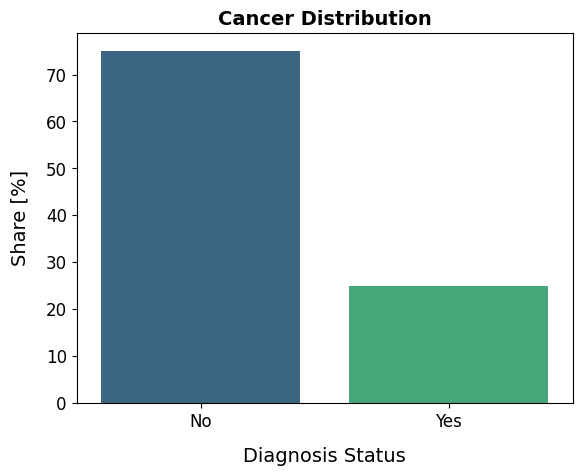

In [11]:
# Plot target distribution

sns.barplot(data=cancer_counts, x='lung_cancer_risk', y='percentage', hue='lung_cancer_risk', palette='viridis')
plt.title('Cancer Distribution', fontsize=14, fontdict={'weight': 'bold'})
plt.xlabel('Diagnosis Status', fontsize=14, labelpad=12)
plt.ylabel('Share [%]', fontsize=14, labelpad=12)
plt.tick_params(axis='x', labelsize=12)
plt.tick_params(axis='y', labelsize=12)
plt.savefig('./plots/lung_cancer_risk_distribution.png', dpi=300)

plt.show()

**Insight:**

Approximately 25% of the population is diagnosed, indicating a moderately imbalanced dataset.

### 5.2. Age Profile of Diagnosed Patients

In [12]:
ave_diag = df2[df2['lung_cancer_risk'] == 'Yes'].groupby('age')['lung_cancer_risk'].count().reset_index()
ave_diag.rename(columns={'lung_cancer_risk': 'count'}, inplace=True)
ave_diag.sort_values(by='age', inplace=True)
ave_diag.head()

,age,count
0,18,2
1,20,1
2,23,2
3,25,1
4,27,1


In [13]:
# Determine optimal number of bins for age distribution (k = 1 + log2(n))

n = len(ave_diag)
n_bins = int(np.ceil(np.log2(n) + 1))
print(f'No. of bins: {n_bins}')

No. of bins: 7


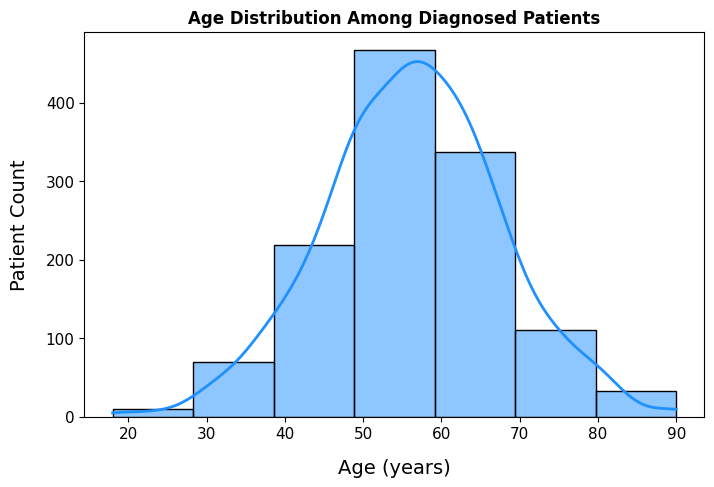

In [16]:
# Age distribution among diagnosed patients

plt.figure(figsize=(8,5))
sns.histplot(data=df2[df2['lung_cancer_risk'] == 'Yes'], x='age', bins=n_bins, kde=True, color='dodgerblue', line_kws={'lw': 2.0})
plt.title('Age Distribution Among Diagnosed Patients', fontsize=12, fontweight='bold')
plt.xlabel('Age (years)', fontsize=14, labelpad=12)
plt.ylabel('Patient Count', fontsize=14, labelpad=12)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.savefig('./plots/histogram_age_distribution.png', dpi=300)

plt.show()

**Insight:**

Diagnosed cases are concentrated between ages 50-60.

### 5.3. Gender Distribution of Diagnosed Cases

In [17]:
# Aggregate number of diagnosed cases by gender
gender_diag = df2.groupby(['gender'])['lung_cancer_risk'].apply(lambda x: (x == 'Yes').sum()).reset_index(name='count')
gender_diag['%'] = (gender_diag['count'] / gender_diag['count'].sum() * 100).round(1)
gender_diag

,gender,count,%
0,Female,610,49.0
1,Male,634,51.0


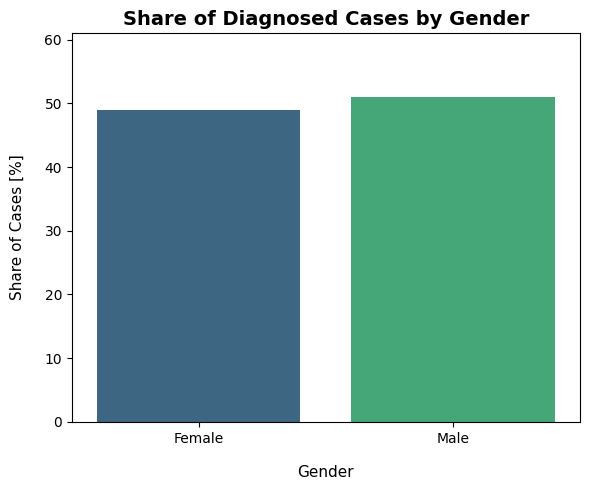

In [18]:
# Visualize gender distribution among diagnosed cases

plt.figure(figsize=(6,5))
sns.barplot(data=gender_diag, x='gender', y='%', hue='gender', palette='viridis', legend=False)
plt.title('Share of Diagnosed Cases by Gender', fontsize=14, fontdict={'weight': 'bold'})
plt.xlabel('Gender', fontsize=11, labelpad=14)
plt.ylabel('Share of Cases [%]', fontsize=11, labelpad=14)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.ylim(0, max(gender_diag['%']) + 10)
plt.tight_layout()
plt.savefig('./plots/distribution_by_gender.png', dpi=300)

plt.show()

**Insight:**

Diagnosed cases are distributed relatively evenly across genders, with a slight predominance among males.

### 5.4. Risk Factors and Patient Profile

#### 5.4.1. Socioeconomic and Access Factors

In [19]:
# Income distribution 
income_diag = df2[df2['lung_cancer_risk'] == 'Yes'].groupby('income_level')['lung_cancer_risk'].count().reset_index(name='count')
income_diag['%'] = (income_diag['count'] / income_diag['count'].sum() * 100).round(1)
income_diag = income_diag.sort_values(by='%', ascending=False)
income_diag

,income_level,count,%
4,Medium,435,35.0
2,Low,405,32.6
3,Lowest,199,16.0
0,High,169,13.6
1,Highest,36,2.9


In [20]:
# Healthcare access levels
healthcare_access_diag = df2[df2['lung_cancer_risk'] == 'Yes'].groupby('healthcare_access')['lung_cancer_risk'].count().reset_index(name='count')
healthcare_access_diag['%'] = (healthcare_access_diag['count'] / healthcare_access_diag['count'].sum() * 100).round(1)
healthcare_access_diag = healthcare_access_diag.sort_values(by='%', ascending=False)
healthcare_access_diag

,healthcare_access,count,%
1,Fair,432,34.7
2,Good,432,34.7
3,Poor,198,15.9
4,Very Good,154,12.4
0,Excellent,28,2.3


In [21]:
# Education level distribution
education_diag = df2[df2['lung_cancer_risk'] == 'Yes'].groupby('education_years')['lung_cancer_risk'].count().reset_index(name='count')
education_diag['%'] = (education_diag['count'] / education_diag['count'].sum() * 100).round(1)
education_diag = education_diag.sort_values(by='%', ascending=False)
education_diag

,education_years,count,%
7,12,173,13.9
6,11,161,12.9
5,10,146,11.7
8,13,141,11.3
4,9,128,10.3
9,14,101,8.1
10,15,85,6.8
3,8,79,6.4
11,16,56,4.5
2,7,52,4.2


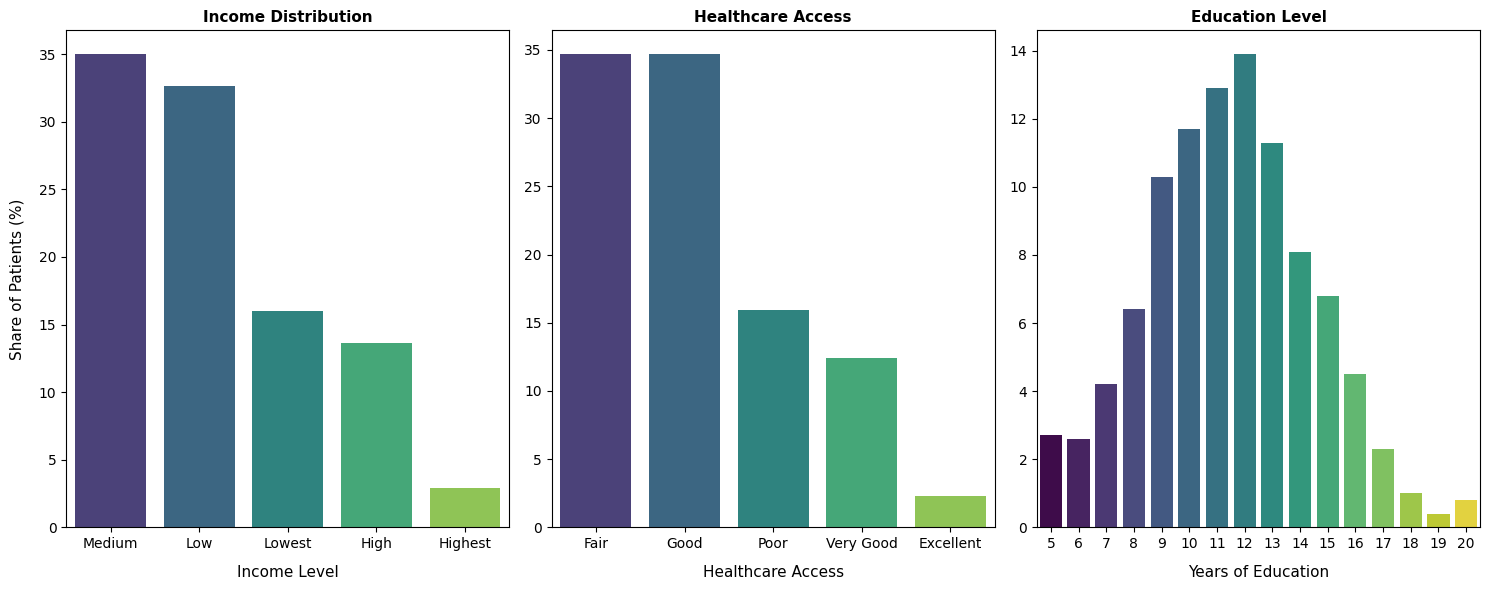

In [22]:
# Visualize socioeconomic and access factors

fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(15,6))

sns.barplot(ax=ax[0], data=income_diag, x='income_level', y='%', hue='income_level', palette='viridis')
ax[0].set_title('Income Distribution', fontsize=11, fontdict={'weight': 'bold'})
ax[0].set_xlabel('Income Level', fontsize=11, labelpad=10)
ax[0].set_ylabel('Share of Patients (%)', fontsize=11, labelpad=10)    
ax[0].tick_params(axis='x', labelsize=10)        
ax[0].tick_params(axis='y', labelsize=10)

sns.barplot(ax=ax[1], data=healthcare_access_diag, x='healthcare_access', y='%', hue='healthcare_access', palette='viridis')
ax[1].set_title('Healthcare Access', fontsize=11, fontdict={'weight': 'bold'})
ax[1].set_xlabel('Healthcare Access', fontsize=11, labelpad=10)
ax[1].set_ylabel('', fontsize=11, labelpad=10)    
ax[1].tick_params(axis='x', labelsize=10)        
ax[1].tick_params(axis='y', labelsize=10)

sns.barplot(ax=ax[2], data=education_diag, x='education_years', y='%', hue='education_years', palette='viridis', legend=False)
ax[2].set_title('Education Level', fontsize=11, fontdict={'weight': 'bold'})
ax[2].set_xlabel('Years of Education', fontsize=11, labelpad=10)
ax[2].set_ylabel('', fontsize=11, labelpad=10)    
ax[2].tick_params(axis='x', labelsize=10)        
ax[2].tick_params(axis='y', labelsize=10)

plt.tight_layout()
plt.savefig('./plots/socioeconomic_factors.png', dpi=300)
plt.show()

**Insights:**

Diagnosed cases are concentrated primarily in low-to-medium income groups and mid-level healthcare access categories.

#### 5.4.2. Lifestyle Risk Factors

In [23]:
# Smoking exposure analysis
smoking_diag = df2.groupby('smoker')['lung_cancer_risk'].apply(lambda x: (x == 'Yes').mean() * 100).reset_index(name='diagnosis_rate[%]').round(1)
smoking_diag.rename(columns={'smoker': 'status'}, inplace=True)
smoking_diag.insert(loc=0, column='metric', value='Active Smoking')
smoking_diag

passive_diag = df2.groupby('passive_smoking')['lung_cancer_risk'].apply(lambda x: (x == 'Yes').mean() * 100).reset_index(name='diagnosis_rate[%]').round(1)
passive_diag.rename(columns={'passive_smoking': 'status'}, inplace=True)
passive_diag.insert(loc=0, column='metric', value='Passive Smoking')

smoking_combined = pd.concat([smoking_diag, passive_diag], ignore_index=True)
smoking_combined

,metric,status,diagnosis_rate[%]
0,Active Smoking,No,0.0
1,Active Smoking,Yes,54.7
2,Passive Smoking,No,23.9
3,Passive Smoking,Yes,26.8


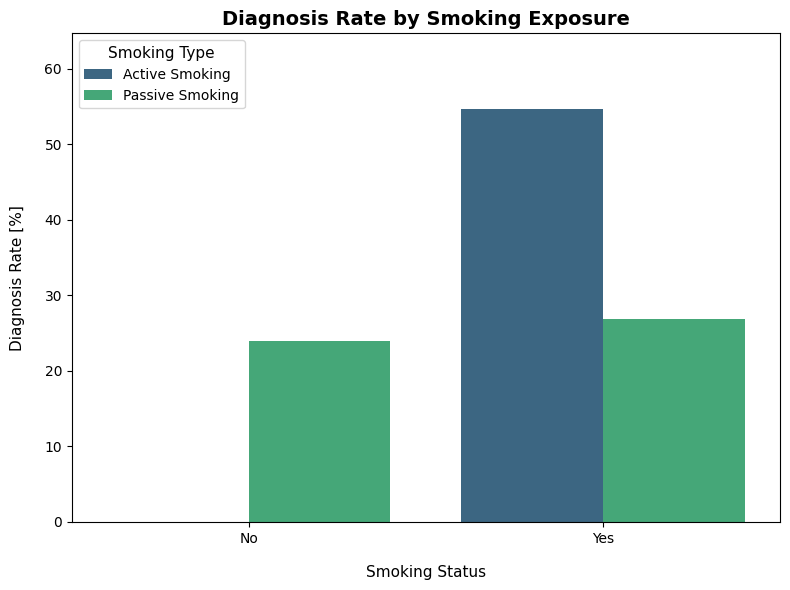

In [24]:
# Smoking exposure by diagnosis status

plt.figure(figsize=(8,6))
sns.barplot(data=smoking_combined, x='status', y='diagnosis_rate[%]', hue='metric', palette='viridis')
plt.title('Diagnosis Rate by Smoking Exposure', fontsize=14, fontdict={'weight': 'bold'})
plt.xlabel('Smoking Status', fontsize=11, labelpad=14)
plt.ylabel('Diagnosis Rate [%]', fontsize=11, labelpad=14)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.ylim(0, max(smoking_combined['diagnosis_rate[%]']) + 10)
plt.legend(title='Smoking Type', fontsize=10, title_fontsize=11, loc='upper left')

plt.tight_layout()
plt.savefig('./plots/smoking_status_diagnosed.png', dpi=300)
plt.show()

**Insights:**

Diagnosis rate is substantially higher among active smokers. Passive exposure shows only a modest difference.

In [25]:
# Passive smoking prevalence (all patients)
passive_smoking_all = df2['passive_smoking'].value_counts(normalize=True) * 100
passive_smoking_all = passive_smoking_all.reset_index()
passive_smoking_all.columns = ['passive_smoking', 'population [%]']
passive_smoking_all.round(1)

,passive_smoking,population [%]
0,No,65.2
1,Yes,34.8


In [26]:
# Lifestyle metric aggregation

smoking_years = df2.groupby('lung_cancer_risk')['smoking_years'].mean().round(1).reset_index(name='smoking [years]')
cigarettes_day = df2.groupby('lung_cancer_risk')['cigarettes_per_day'].mean().round(1).reset_index(name='cigarettes/day [units]')
pack_years = df2.groupby('lung_cancer_risk')['pack_years'].mean().round(1).reset_index(name='pack/year [units]')
alcohol_week = df2.groupby('lung_cancer_risk')['alcohol_units_per_week'].mean().round(1).reset_index(name='alcohol/week [units]')
exercises_week = df2.groupby('lung_cancer_risk')['exercise_hours_per_week'].mean().round(1).reset_index(name='exercise_hours/week [units]')
bmi = df2.groupby('lung_cancer_risk')['bmi'].mean().round(1).reset_index(name='BMI')

lifestyle_factors = smoking_years.merge(cigarettes_day, on='lung_cancer_risk').merge(pack_years, on='lung_cancer_risk').merge(alcohol_week, on='lung_cancer_risk').merge(exercises_week, on='lung_cancer_risk').merge(bmi, on='lung_cancer_risk')
lifestyle_factors = lifestyle_factors.melt(id_vars='lung_cancer_risk', var_name='metric', value_name='value')
lifestyle_factors.rename(columns={'lung_cancer_risk': 'diagnosis_status'}, inplace=True)
lifestyle_factors

,diagnosis_status,metric,value
0,No,smoking [years],4.0
1,Yes,smoking [years],23.4
2,No,cigarettes/day [units],2.8
3,Yes,cigarettes/day [units],18.5
4,No,pack/year [units],1.5
5,Yes,pack/year [units],20.6
6,No,alcohol/week [units],5.8
7,Yes,alcohol/week [units],6.0
8,No,exercise_hours/week [units],2.6
9,Yes,exercise_hours/week [units],2.4


In [27]:
# Diet quality distribution
diet_diag = df2[df2['lung_cancer_risk'] == 'Yes'].groupby('diet_quality')['lung_cancer_risk'].count().reset_index(name='count')
diet_diag['%'] = (diet_diag['count'] / diet_diag['count'].sum() * 100).round(1)
diet_diag = diet_diag.sort_values(by='%', ascending=False)
diet_diag

,diet_quality,count,%
1,Fair,446,35.9
2,Good,426,34.2
3,Poor,183,14.7
4,Very Good,160,12.9
0,Excellent,29,2.3


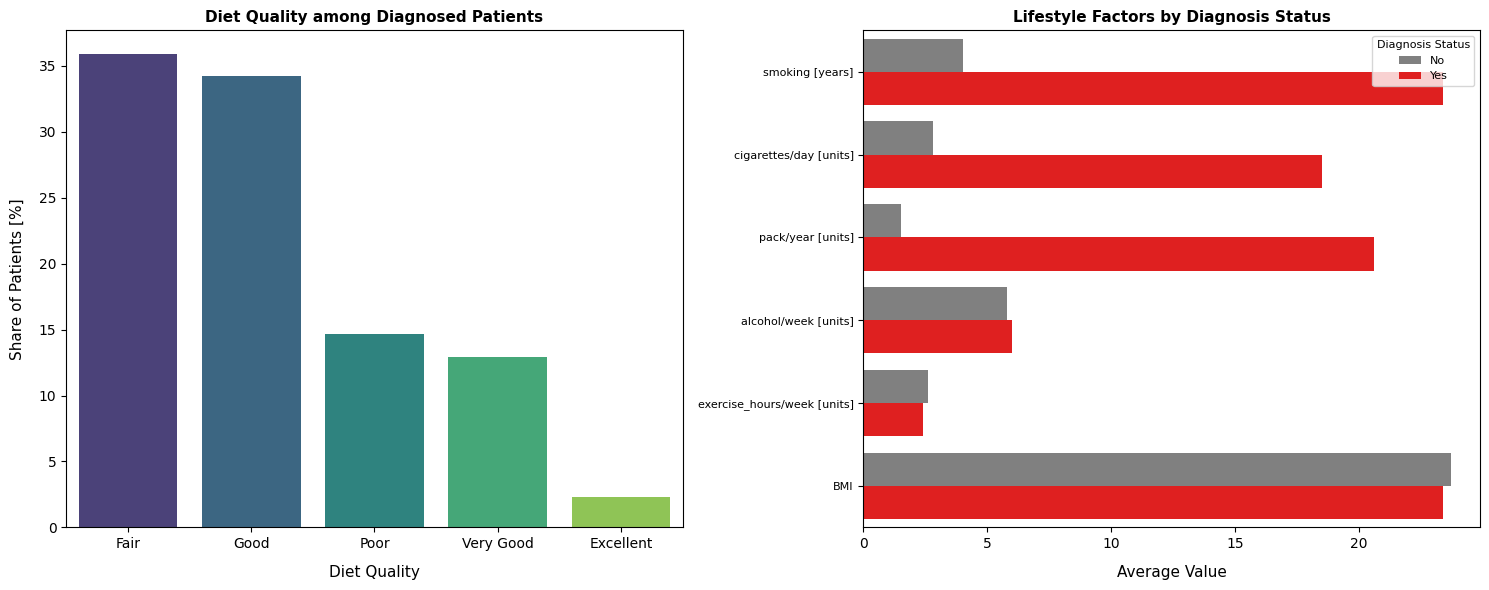

In [28]:
# Lifestyle factors comparison

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(15,6))

sns.barplot(ax=ax[0], data=diet_diag, x='diet_quality', y='%', hue='diet_quality', palette='viridis')
ax[0].set_title('Diet Quality among Diagnosed Patients', fontsize=11, fontdict={'weight': 'bold'})
ax[0].set_xlabel('Diet Quality', fontsize=11, labelpad=10)
ax[0].set_ylabel('Share of Patients [%]', fontsize=11, labelpad=10)
ax[0].tick_params(axis='x', labelsize=10)        
ax[0].tick_params(axis='y', labelsize=10)

sns.barplot(ax=ax[1], data=lifestyle_factors, y='metric', x='value', hue='diagnosis_status', orient='h', palette={'Yes': 'red', 'No': 'gray'})
ax[1].set_title('Lifestyle Factors by Diagnosis Status', fontsize=11, fontdict={'weight': 'bold'})
ax[1].set_xlabel('Average Value', fontsize=11, labelpad=10)
ax[1].set_ylabel('', fontsize=11, labelpad=10)
ax[1].tick_params(axis='x', labelsize=10)        
ax[1].tick_params(axis='y', labelsize=8)
ax[1].legend(title='Diagnosis Status', fontsize=8, title_fontsize=8, loc='upper right')

plt.tight_layout()
plt.savefig('./plots/lifestyle_factors.png', dpi=300)
plt.show()

**Insights:**

- Diagnosed patients are concentrated mainly in fair-to-good diet quality groups.
- Smoking-related metrics show the largest separation between diagnosed and non-diagnosed patients.
- BMI and exercise levels show relatively small differences between groups.

#### 5.4.3. Environmental Exposure Factors

In [29]:
# Occupational exposure analysis

occupational_factor = df2.groupby('occupational_exposure')['lung_cancer_risk'].apply(lambda x: (x == 'Yes').mean() * 100).reset_index(name='diagnosis_rate[%]').round(1)
occupational_factor

,occupational_exposure,diagnosis_rate[%]
0,No,24.6
1,Yes,25.8


In [30]:
# Radon exposure analysis

radon_factor = df2.groupby('radon_exposure')['lung_cancer_risk'].apply(lambda x: (x == 'Yes').mean() * 100).reset_index(name='diagnosis_rate[%]').round(1)
radon_factor

,radon_exposure,diagnosis_rate[%]
0,No,24.0
1,Yes,29.8


In [31]:
# Air pollution index summary by diagnosis status

air_pollution_factor = df2.groupby('lung_cancer_risk')['air_pollution_index'].describe().round(2)
air_pollution_factor = air_pollution_factor.reset_index()
air_pollution_factor.rename(columns={'lung_cancer_risk': 'diagnosis_status'}, inplace=True)
air_pollution_factor

,diagnosis_status,count,mean,std,min,25%,50%,75%,max
0,No,3756.0,63.72,19.49,20.0,50.0,64.0,77.0,130.0
1,Yes,1244.0,65.97,19.37,20.0,53.0,66.0,79.0,127.0


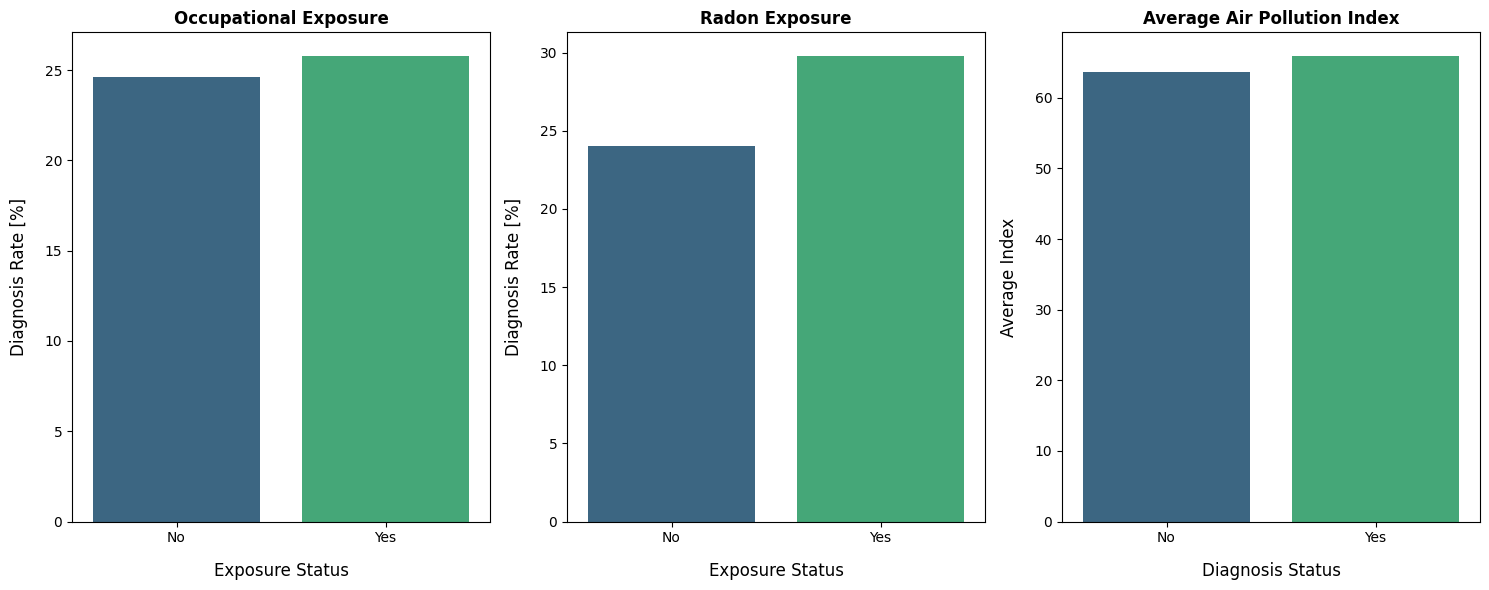

In [32]:
# Environmental exposure comparison

fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(15,6))

sns.barplot(ax=ax[0], data=occupational_factor, x='occupational_exposure', y='diagnosis_rate[%]', hue='occupational_exposure', palette='viridis')
ax[0].set_title('Occupational Exposure', fontsize=12, fontdict={'weight': 'bold'})
ax[0].set_xlabel('Exposure Status', fontsize=12, labelpad=12)
ax[0].set_ylabel('Diagnosis Rate [%]', fontsize=12, labelpad=12)    

sns.barplot(ax=ax[1], data=radon_factor, x='radon_exposure', y='diagnosis_rate[%]', hue='radon_exposure', palette='viridis')
ax[1].set_title('Radon Exposure', fontsize=12, fontdict={'weight': 'bold'})
ax[1].set_xlabel('Exposure Status', fontsize=12, labelpad=12)
ax[1].set_ylabel('Diagnosis Rate [%]', fontsize=12, labelpad=12)

sns.barplot(ax=ax[2], data=air_pollution_factor, x='diagnosis_status', y='mean', hue='diagnosis_status', palette='viridis', legend=False)
ax[2].set_title('Average Air Pollution Index', fontsize=12, fontdict={'weight': 'bold'})
ax[2].set_xlabel('Diagnosis Status', fontsize=12, labelpad=12)
ax[2].set_ylabel('Average Index', fontsize=12, labelpad=12)

plt.tight_layout()  
plt.savefig('./plots/exposures_factors.png', dpi=300)
plt.show()

**Insights:**

- Occupational exposure shows only a marginal increase in diagnosis rate.
- Radon exposure is associated with a moderately higher diagnosis rate.
- Average air pollution levels remain comparable across diagnosis groups.

#### 5.4.4. Respiratory Profile

In [33]:
# Average Oxygen saturation by diagnosis status
oxygen_factor = df2.groupby('lung_cancer_risk')['oxygen_saturation'].mean().round(1).reset_index(name='oxygen_saturation')
oxygen_factor.rename(columns={'lung_cancer_risk': 'diagnosis_status'}, inplace=True)
oxygen_factor

,diagnosis_status,oxygen_saturation
0,No,97.6
1,Yes,91.5


In [34]:
# Average Lung function by diagnosis status
fev1_factor = df2.groupby('lung_cancer_risk')['fev1_x10'].mean().round(1).reset_index(name='FEV1_x10')
fev1_factor.rename(columns={'lung_cancer_risk': 'diagnosis_status'}, inplace=True)
fev1_factor

,diagnosis_status,FEV1_x10
0,No,33.8
1,Yes,24.3


In [35]:
# Combine respiratory metrics
respiratory_profile = oxygen_factor.merge(fev1_factor, on='diagnosis_status')
respiratory_profile = respiratory_profile.melt(id_vars='diagnosis_status', var_name='metric', value_name='value')
respiratory_profile['metric'] = respiratory_profile['metric'].replace({'oxygen_saturation': 'Oxygen Saturation','FEV1_x10': 'Fev1 x10'})
respiratory_profile

,diagnosis_status,metric,value
0,No,Oxygen Saturation,97.6
1,Yes,Oxygen Saturation,91.5
2,No,Fev1 x10,33.8
3,Yes,Fev1 x10,24.3


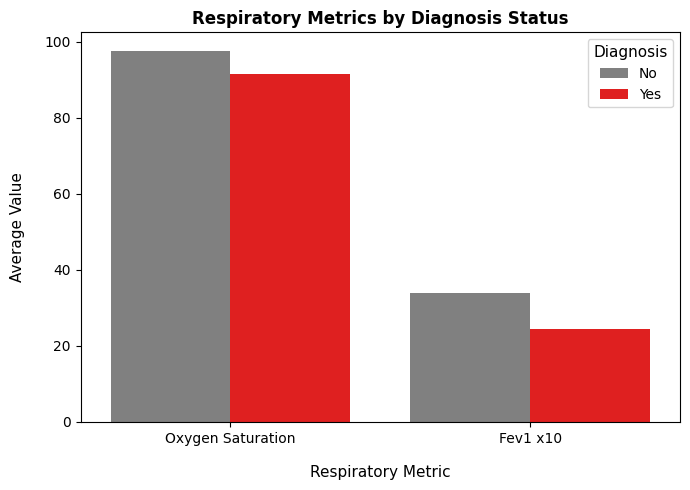

In [38]:
# Compare respiratory metrics between groups

fig, ax = plt.subplots(figsize=(7,5))
sns.barplot(data=respiratory_profile, x='metric', y='value', hue='diagnosis_status', palette={'Yes': 'red', 'No': 'gray'})
plt.title('Respiratory Metrics by Diagnosis Status', fontsize=12, fontdict={'weight': 'bold'})
plt.xlabel('Respiratory Metric', fontsize=11, labelpad=14)
plt.ylabel('Average Value', fontsize=11, labelpad=14)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.legend(title='Diagnosis', fontsize=10, title_fontsize=11, loc='upper right')
plt.tight_layout()
plt.savefig('./plots/respiratory_profile.png', dpi=300)
plt.show()

**Insights:**

Respiratory function metrics are consistently lower among diagnosed patients, indicating impaired pulmonary performance.

#### 5.4.5. Clinical Biomarkers

In [41]:
# Inflammatory marker analysis

marker = df2.groupby('lung_cancer_risk')['crp_level'].mean().round(1).reset_index(name='CRP Level')
marker.rename(columns={'lung_cancer_risk': 'diagnosis_status'}, inplace=True)
marker

,diagnosis_status,CRP Level
0,No,2.2
1,Yes,11.8


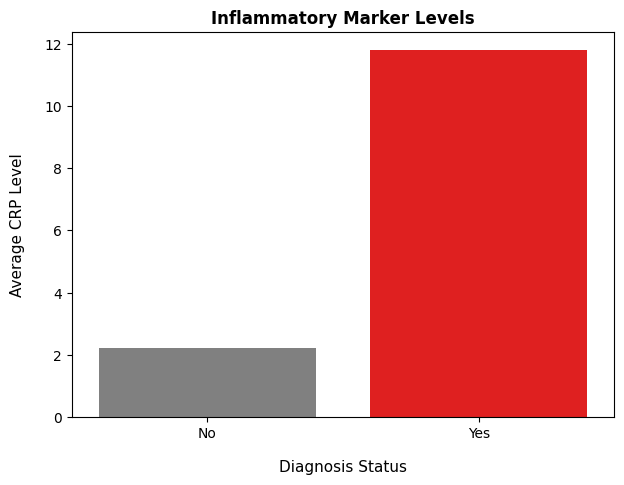

In [ ]:
# Clinical biomarker comparison
plt.figure(figsize=(7,5))
sns.barplot(data=marker, x='diagnosis_status', y='CRP Level', hue='diagnosis_status', palette={'Yes': 'red', 'No': 'gray'}, legend=False)
plt.title('Inflammatory Marker Levels', fontsize=12, fontdict={'weight': 'bold'})
plt.xlabel('Diagnosis Status', fontsize=11, labelpad=14)
plt.ylabel('Average CRP Level', fontsize=11, labelpad=14)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.savefig('./plots/crp_comparison.png', dpi=300)

plt.show()

**Insights:**

Diagnosed patients exhibit substantially elevated CRP levels, indicating significantly higher systemic inflammation compared to non-diagnosed individuals.

#### 5.4.6. Clinical Symptoms

In [39]:
# Analyze frequency occurence of clinical symptom among diagnosed patients

symptoms_diag = ['xray_abnormal','shortness_of_breath','chronic_cough','copd', 'fatigue','chest_pain', 'family_history_cancer','asthma','previous_tb']

def analyze_symptom_frequency(df2,symptoms_diag):
    diagnosed = df2[df2['lung_cancer_risk'] == 'Yes']
    results = []

    for x in symptoms_diag:
        share_yes = ((diagnosed == 'Yes')[x].mean()*100).round(1)
        results.append({'symptom': x, 'prevalence[%]': share_yes})

    return pd.DataFrame(results)

symptom_frequency = analyze_symptom_frequency(df2, symptoms_diag)
symptom_frequency['symptom'] = symptom_frequency['symptom'].replace({   'xray_abnormal': 'Abnormal X-Ray',
                                                                        'shortness_of_breath': 'Shortness of Breath',
                                                                        'chronic_cough': 'Chronic Cough',
                                                                        'copd': 'COPD',
                                                                        'fatigue': 'Fatigue',
                                                                        'chest_pain': 'Chest Pain',
                                                                        'family_history_cancer': 'Family History',
                                                                        'asthma': 'Asthma',
                                                                        'previous_tb': 'Previous TB'
                                                                    })

symptom_frequency


,symptom,prevalence[%]
0,Abnormal X-Ray,72.3
1,Shortness of Breath,65.9
2,Chronic Cough,58.6
3,COPD,55.1
4,Fatigue,39.5
5,Chest Pain,25.5
6,Family History,24.8
7,Asthma,14.9
8,Previous TB,9.0


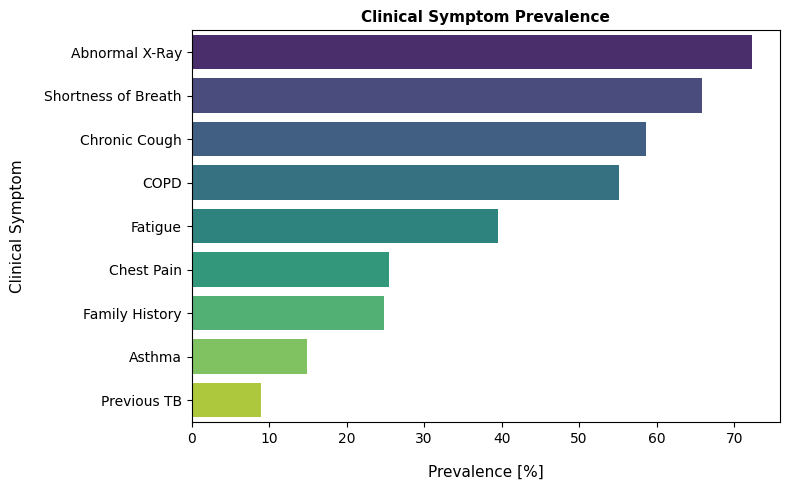

In [40]:
# Plot clinical symptoms and pre-existing conditions

plt.figure(figsize=(8,5))
sns.barplot(data=symptom_frequency, x='prevalence[%]', y='symptom', hue='symptom', palette='viridis')
plt.title('Clinical Symptom Prevalence', fontsize=11, fontdict={'weight': 'bold'})
plt.xlabel('Prevalence [%]', fontsize=11, labelpad=14)
plt.ylabel('Clinical Symptom', fontsize=11, labelpad=14)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.savefig('./plots/symptom_prevalence.png', dpi=300)
plt.show()

**Insights:**

- Respiratory symptoms dominate the diagnosed patient profile.
- Abnormal X-ray findings represent the strongest clinical indicator.
- COPD and chronic cough are frequently associated with diagnosis.
- Fatigue shows moderate prevalence among diagnosed patients.
- Family history and chest pain demonstrate secondary clinical relevance.
- Asthma and previous tuberculosis contribute limited prevalence.

## 6. Key Findings Summary

- Diagnosed cases account for approximately 25% of the dataset and are concentrated primarily among patients aged 50–60.
- Gender distribution remains relatively balanced, with a slight predominance among males.
- Active smoking emerges as the strongest lifestyle-related risk factor.
- Smoking intensity and long-term tobacco exposure are substantially higher among diagnosed patients.
- Occupational exposure shows limited association with diagnosis, while radon exposure demonstrates a moderate increase in diagnosis prevalence.
- Air pollution levels remain relatively comparable across diagnosis groups.
- Diagnosed patients exhibit reduced respiratory performance, including lower oxygen saturation and lung function metrics.
- CRP levels are substantially elevated among diagnosed patients, indicating increased systemic inflammation.
- Respiratory symptoms dominate the diagnosed patient profile.
- Abnormal X-ray findings, chronic cough, and COPD represent the most prevalent clinical indicators.
- Family history and chest pain demonstrate moderate clinical relevance.
- Asthma and previous tuberculosis show comparatively limited prevalence among diagnosed patients.